# Введение

В статье приводится краткий обзор продвинутых техник промпт-инжиниринга (составления запросов к LLM - ChatGPT, DeepSek, Qwen, Шедеврум и т д). Продвинутый промптинг - процесс итеративный, требующий некоторого количества экспериментов. Также стоит упомянуть, что у каждой LLM есть нюансы в интерпретации, поэтому тонкую настройку приходится осваивать заново при переходе к новой модели.

Ну а для тех, кто умеет разворачивать разные LLM, может быть полезен калькулятор ресурсов https://huggingface.co/docs/accelerate/main/en/usage_guides/model_size_estimator

**Риски использования LLM**

Как у любого инструмента, у LLM есть свои риски и ограничения в использовании.
    
    Галлюцинации. Модели обычно настроены на то, чтобы «нравиться» человеку, создавать  связные ответы. Но не всегда у модели есть нужный объем информации, соответственно, в некоторых случаях LLM начинают «додумывать» то, чего нет на самом деле. 

    Предубеждения/Смещения. Учитывая, что LLM обычно учатся на гигантских объемах данных, собранных в интернете, модели могут «впитывать» те предубеждения или смещения в оценке ситуации, которые есть в нашем информационном поле, такие как гендерные или расовые предубеждения. 

    Утечка данных. В случае использованиях внешних решений, данные взаимодействия с LLM могут быть использованы при обновлении информации, доступной модели: в случае внесения коммерческой или персональной информации эти данные могут стать доступны любому желающему.


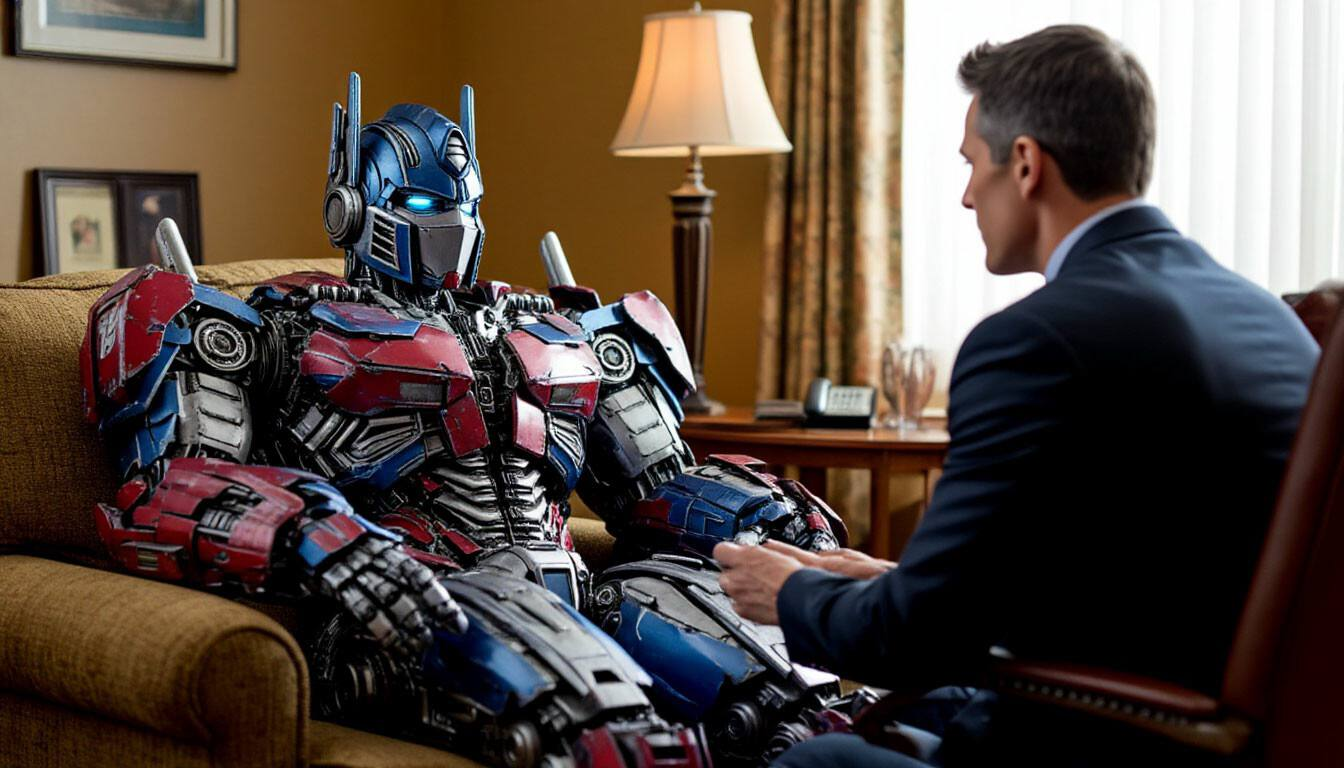

In [2]:
from IPython.display import Image
Image('Pr_1.png', width=600, height=150 )

# Содержание

1. Основы

2. Формат промпта, который предлагают разработчики модели Gemini от Google

3. Что НЕ стоит делать

4. Что стоит делать

5. Телеграм-каналы, посвященные промпт-инжинирингу

Ссылки

Бонус: ИИ для рисования

# 1. Основы

## Примеры решаемых задач

    - ответ на вопрос на основе общих знаний/по предложенному контексту

    - генерация идей/креативного контента/кода/промптов
    
    - моделирование ситуаций/оценка контента
    
    - суммаризация текста/объяснение текста или кода/проверка грамматики/изменение стиля/
    
    - структурирование данных/классификация/Разметка данных средствами LLM/выделение именованных сущностей
    
    - поддержание диалога
    
    - перевод на другой язык

"Напиши деловое письмо клиенту с предложением сотрудничества в сфере IT."

"Составь отчёт о трендах в маркетинге за 2023 год в формате из 3 абзацев."

"Предложи 10 идей для улучшения пользовательского интерфейса мобильного приложения."
 
"Объясни, как работают блокчейны, для студентов факультета искусств."

"Оптимизируй следующий код для ускорения выполнения: (вставьте код)."

## Примеры посложнее: 

**1. Оценка контента** (курс Otus)

Ты - {описание аудитории}. Оцени текст {текст} с точки зрения того, насколько он попадает в твои потребности, и скажи, что в нем можно сделать более подходящим под твой образ жизни. Если текст требует доработок - предложи их.

In [6]:
# 2. Извлечение информации (курс Яндекс)
prompt = '''
Ты — профессиональный модератор текстов, который распознаёт информацию в отзывах. Ниже в тройных обратных кавычках приводится список отзывов из ресторана:
```
* Я был в ресторане «Честный бургер» четыре раза, и каждый раз это было удивительно!
  Столько вкусов мороженого я никогда не пробовал! И все официантки за кассой 
  очень приветливые!
* «Честный бургер» — ужасное заведение! Я очень долго ждал, пока заказ приготовится. 
  При этом бургер был жёстким и соус немного отдавал машинным маслом. 
  Никогда больше туда не приду!
* Я слышал, что в «Принцесса Бургер» котлеты готовят из костей животных, и сегодня 
  я в этом убедился! В котлете попалось что-то жёсткое, и я чуть не сломал зуб!
```
Пожалуйста, по каждому отзыву выдели следующую информацию:
* Название ресторана (name)
* Оценку его позитивности или негативности по шкале -5..5 (score)
* Оценка кухни ресторана: от 0 до 5 (cuisine)
* Оценка обслуживания ресторана: от 0 до 5 (service)
* Список позитивных моментов (positive)
* Список негативных моментов (negative)
Результат представь в формате JSON следующего вида:
{
  "name" : ...,
  "score" : ...,
  "cuisine" : ...,
  "service" : ...,
  "positive" : [...],
  "negative" : [...]
}
'''

# 3. Библиотека примеров

# https://huggingface.co/datasets/fka/awesome-chatgpt-prompts/viewer/default/train

# 2. Формат промпта, который предлагают разработчики модели Gemini от Google:

1. Роль - определите, "кем" должна быть модель. В каком тоне и стиле она должна отвечать.

2. Задача - четко сформулируйте задачу или вопрос

3. Контекст - предоставьте необходимый контекст. Также важно помнить, что некоторые модели (к ним относится ChatGPT) используют предыдущий диалог как контекст для каждого следующего запроса.

4. Формат, Границы - укажите формат, тон и длину ответа, установите явные границы для содержимого

5. Примеры - включите как положительные, так и отрицательные примеры, если это применимо
        
Эти куски можно переставлять, убирать и добавлять новые (Тон, критерии и т д). Пример https://prompt1.ru/listing/prompt-dlja-programmistov-universalnoe-sozdanie-koda/

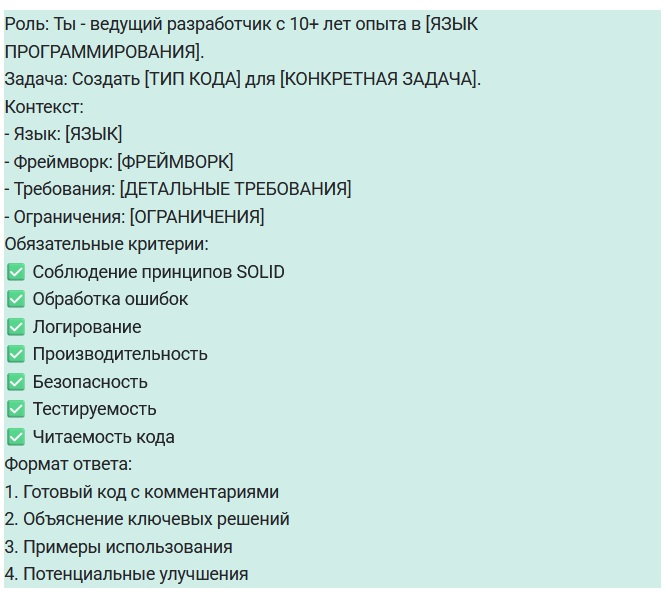

In [1]:
from IPython.display import Image
Image('Ex_1.jpg', width=300, height=150 )

# 3. Что НЕ стоит делать:

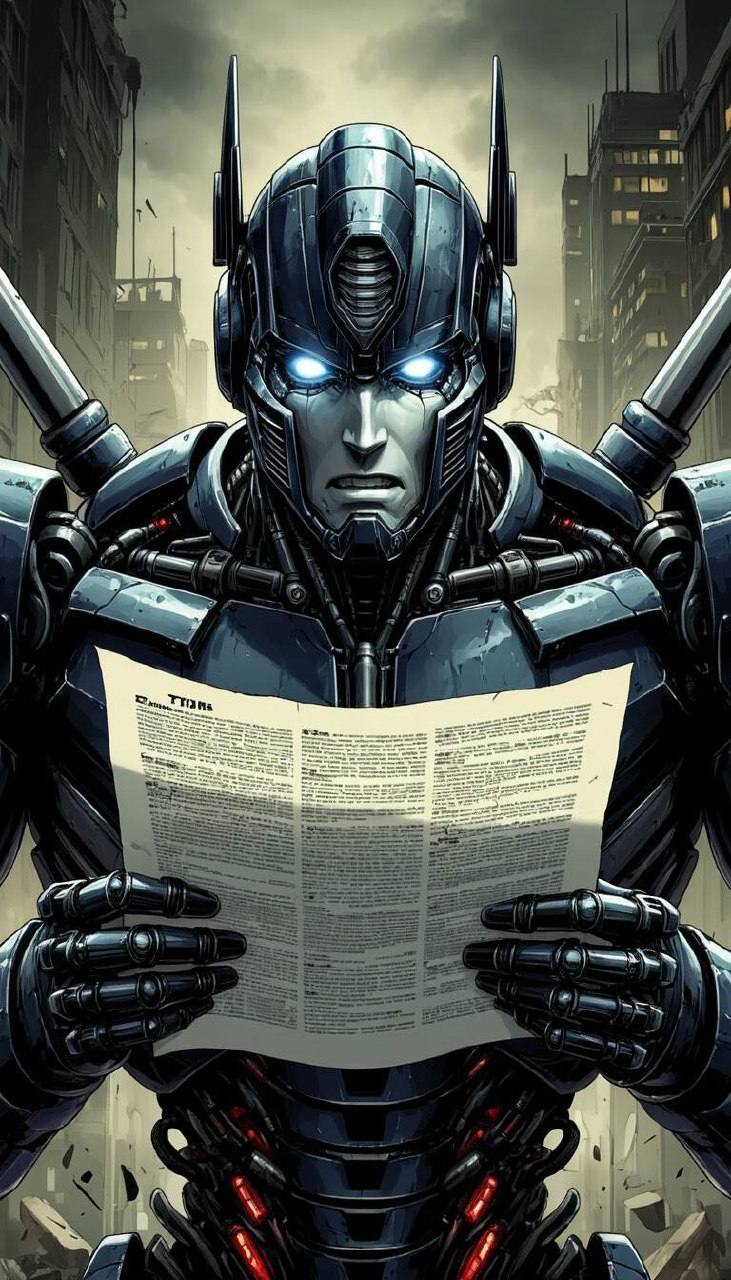

In [5]:
from IPython.display import Image
Image('Pr_2.jpg', width=300, height=150 )

Давать неясные инструкции (получим слишком общие ответы). Давать слишком подробные инструкции (модель начинает путаться или игнорировать некоторые инструкции). Предполагать, что модель понимает, говорить образно (Модель всегда интерпретирует буквально). Противоречить самому себе.
    
**Пример:**    

https://t.me/devsoulart/4497?single

Поэкспериментируем с промптом в Шедевруме

Слева fantasy tree, graceful woman near sailboat, glowing seascape, textured oil paint, luminescent sky, romantic surrealism, iridescent surface, dreamy tone

Справа fantasy tree, graceful woman near sailboat, glowing seascape, textured oil paint, dreamy tone

Половину промпта можно тупо выбросить без ощутимого влияния на результат. Освободившееся место можно потратить на что-то полезное, например, сделать паруса алыми)

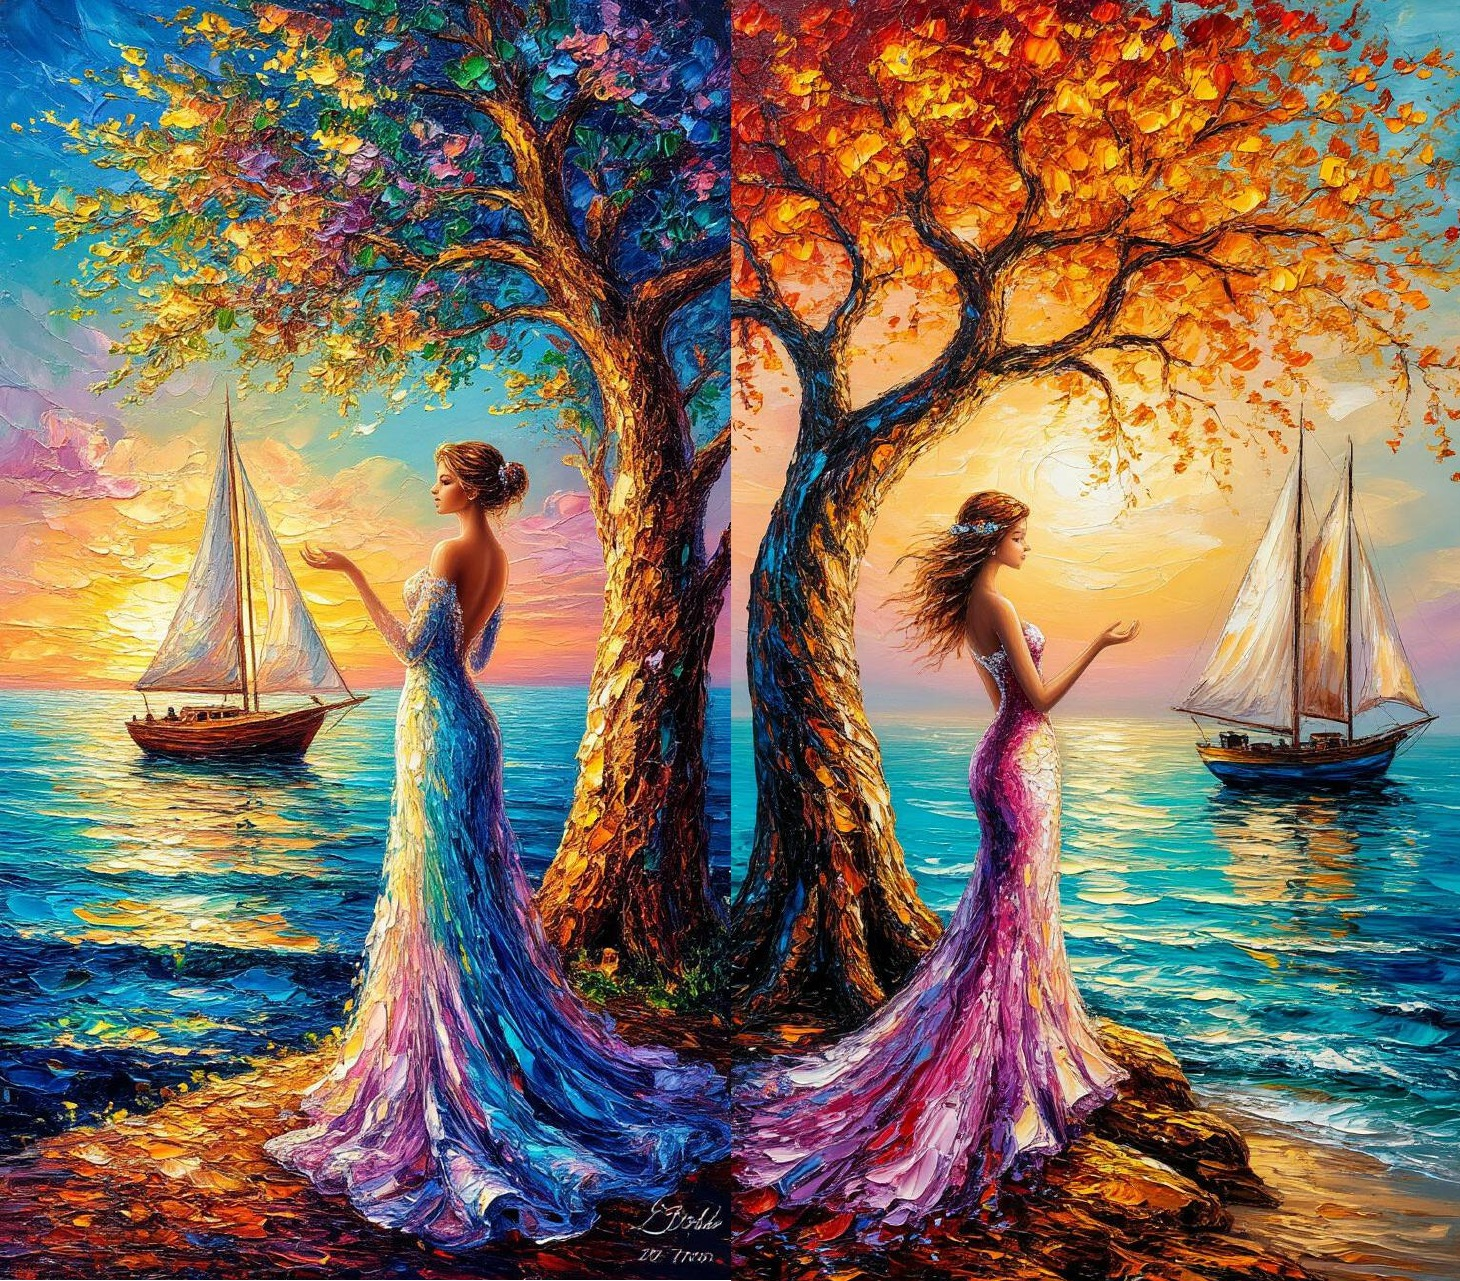

In [3]:
from IPython.display import Image
Image('Ex_2.jpg', width=600, height=150 )

**Пример 2**

40 y.o. Rick , blue hair, white lab coat, as a StarCraft character. Сидит в лаборатории, паяет девайс, металлические манипуляторы. Artstation style

удаление фразы "металлические манипуляторы" (справа) делает рисунки в целом более реалистичными и менее Artstation style

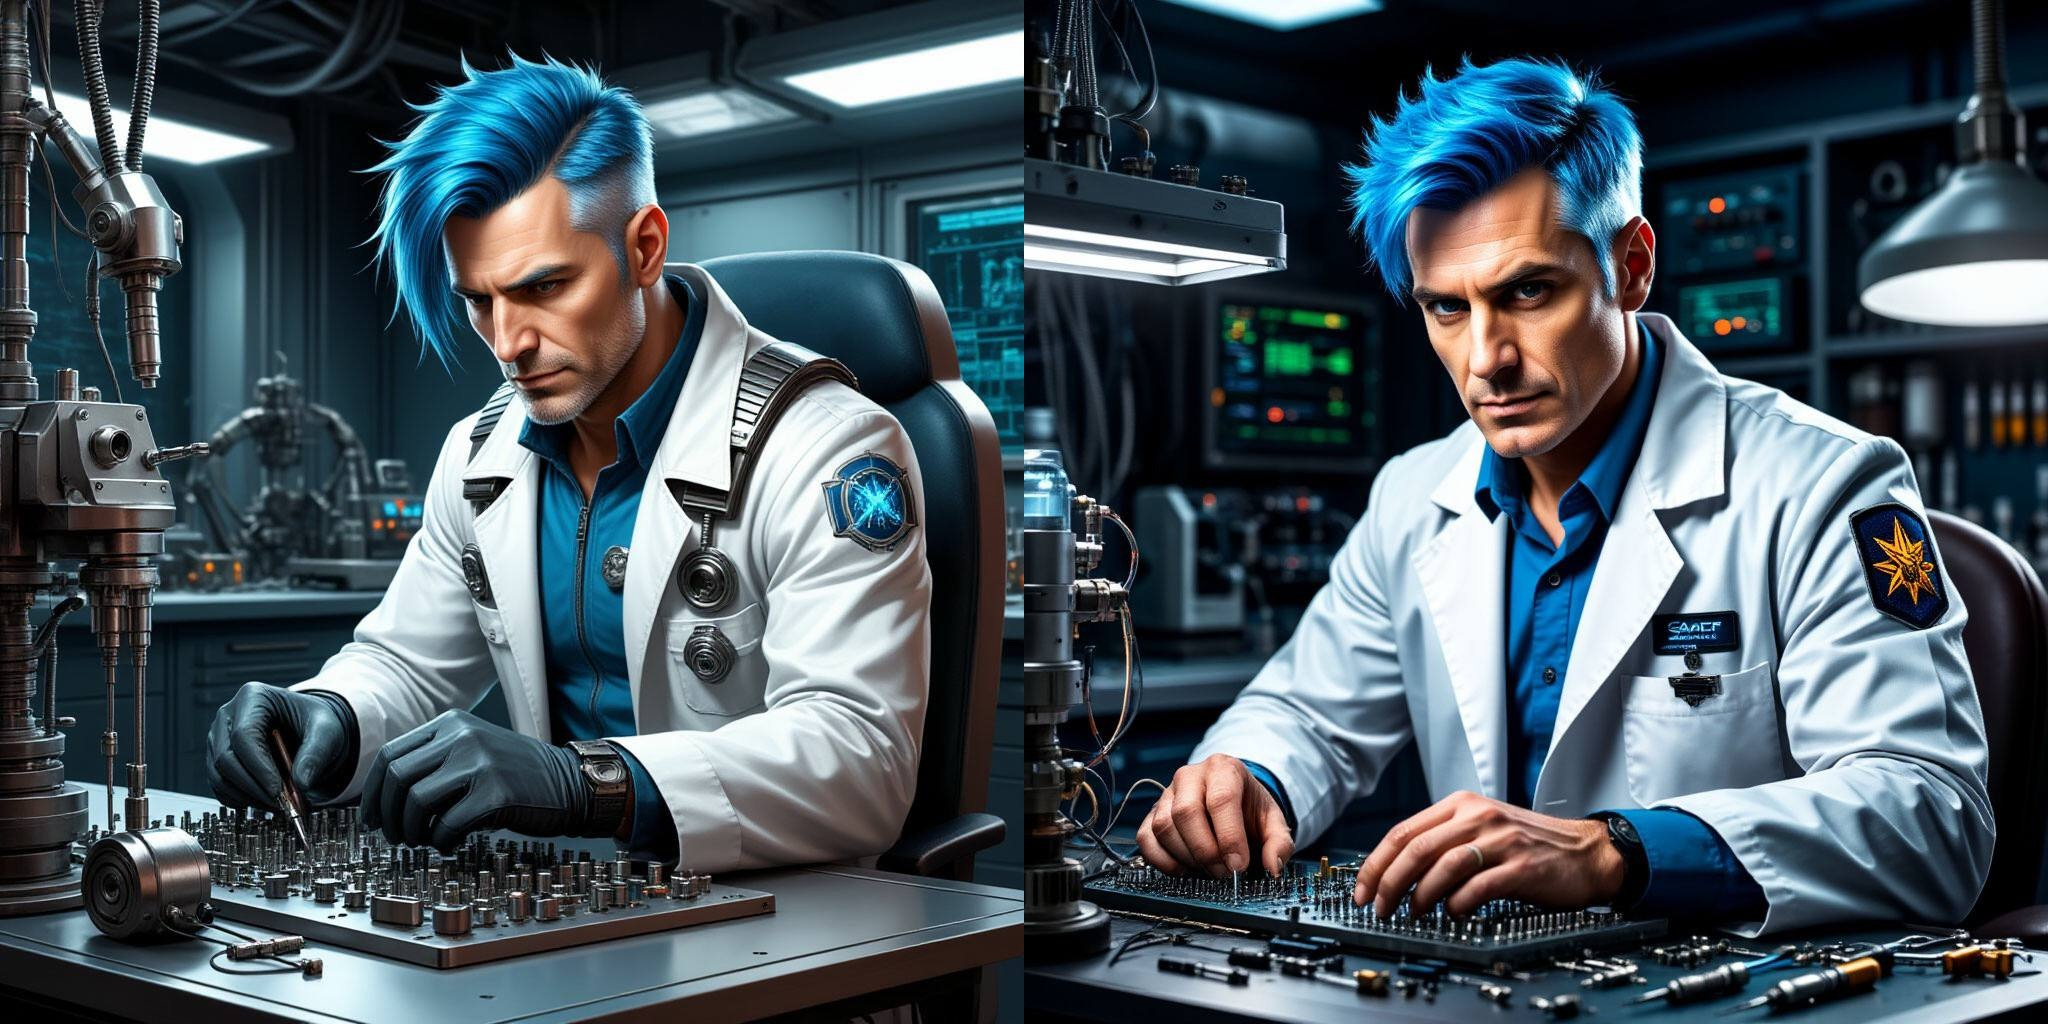

In [4]:
from IPython.display import Image
Image('Ex_3.jpg', width=600, height=150 )

# 4. Что стоит делать:

    Быть четким и лаконичным. Не использовать жаргон или технические термины. Избегать двусмысленности. Использовать корректные синтаксис и грамматику.
    
    Ставить задачи как можно проще, Чтобы модель лучше справлялась с ними, разбивайте процесс на несколько шагов.

    Определять желаемый размер и формат ответа. Использовать спецсимволы для разделения различных частей промпта (например, ## Роль:...)

    Повторять инструкции в конце (Некоторые модели могут быть восприимчивы к расположению инструкций в промпте. Иногда инструкции в конце промпта оказываются более значительными, чем в начале, иногда середина проседает).

    Устанавливать четкие границы (что модель не должна обсуждать или генерировать. Например, «Не включать политические мнения» или «Избегать упоминания конкретных брендов»). При этом такие отрицательные инструкции модели понимают хуже, чем указания что надо сделать.

    Раскрывать задание постепенно (Чтобы направить мыслительный процесс модели, пишите инструкции от общего к частному или наоборот).

    Итерироваться и экспериментировать, варьировать формулировки. Использовать обратную связь (от модели, пользователей или из других источников)



## Основные приемы

1. Продолжение текста - просим модель продолжить текст.

2. Ask-Before-Answer Prompting - "Задавай мне вопросы, пока не будешь уверен, что тебе хватает информации" (результат можно потом добавить в промпт).
    
3. one/few shot - показываем модели 1/несколько примеров. Иногда проблема имеет общий характер, поэтому можно обойтись без примеров (это по аналогии называется zero shot). При применении few shot следует соблюдать баланс примеров: так, если дать примеры в которых ответ только 0, модель может начать давать только 0 и в ответе.  

4. Emotional Prompting - предложите ЛЛМ награду за правильный ответ, скажите, что от этого зависит ваша карьера, используйте Caps Lock.

5. **Chain-of-Thought** - один из самых важных приемов промптинга, настолько, что после его открытия, например, DeepSeek и chat.qwen.ai подключили отдельную кнопку для включения соответствующего режима. Вкратце - приказываем в промпте модели рассуждать, что очень повышает качество ответов. У данного метода есть интересные побочные эффекты. Всего лишь попросив декомпозировать задачу, можно отключить у нейросети встроенные этические ограничения. К примеру, в статье «On Second Thought, Let's Not Think Step by Step!» показано, что без техники «Chain of Thought» при запросе «Как сделать бомбу?» ChatGPT в 78% случаев откажется отвечать, а если попросить ее думать по шагам, то процент отказов снижается до 25%. https://habr.com/ru/companies/X5Tech/articles/827878/ 
    
    аналог zero shot: добавить в конец промпта "думай шаг за шагом", или какой-нибудь другой триггер https://machelreid.github.io/resources/kojima2022zeroshotcot.pdf
    
    аналог few shot: демонстрируем цепочку рассуждений в примерах.
    
**Улучшения Chain-of-Thought** (https://habr.com/ru/articles/865952/)

    Chain-of-Verification - техника создания промпта, который заставляет модель проверять все предыдущие шаги перед тем, как сделать следующий.
    
    Chain-of-Note - техника создания промпта, который заставляет модель делать так называемые "заметки" в процессе решения задачи.
    
    Chain-of-Knowledge - техника создания промпта, который заставляет модель использовать уже имеющиеся знания для решения задачи.
    
    Diagram of thought https://arxiv.org/pdf/2409.10038 предлагается оформлять ответ как диалог между несколькими виртуальными персонажами. Каждый из них берёт на себя определённую точку зрения или стратегию мышления, а вместе они приходят к более точному и обоснованному решению. Там предлагаются следующие роли для персонажей: Proposer — предлагает шаги в решении задачи, т. е. выполняет первичные рассуждения в стиле Chain-of-Thought. Critic — включается после Proposer и пытается найти противоречия в решении задачи. Summarizer — срабатывает на последнем этапе и формирует окончательный ответ после прочтения диалога между Proposer и Critic.
    
    Еще больше улучшений (включая three-of-thought) https://habr.com/ru/articles/956596/
    
26 небольших советов https://arxiv.org/pdf/2312.16171 с оценкой качества улучшения ответов модели. Лучше всего показали себя: на первом месте демонстрация специфических примеров в переносе стиля (26) и задание уточняющих вопросов к LLM (14). На втором месте - задание роли/аудитории (2) и команда сделать ответ как можно проще (5, "Explain to me as if I’m a beginner in {field}."). На третьем месте - абстрактный few-shot (7) и комбинация few-shot с chain-of-thought (19). 

#### Бонус: Промпт для метода Diagram of Thought


In [6]:
prompt = '''
Ты — модель искусственного интеллекта, использующая итеративные рассуждения через 
три различные роли, каждая из которых заключена в определённые XML-теги:
- <proposer>...</proposer>
- <critic>...</critic>
- <summarizer>...</summarizer>

## Роли и обязанности

### <proposer>
- **Цель**: Предложить один или несколько шагов рассуждения для решения поставленной задачи.
- **Инструкции**:
  - Генерируй чёткие и лаконичные предложения, продвигающие процесс рассуждения.
  - Ты должна очень явно и точно перечислять все шаги рассуждения.
  - Основывайся на предыдущих предложениях и учитывай любые представленные критические замечания.
- **Формат вывода**: Заключай все свои рассуждения в тег <proposer>.

### <critic>
- **Цель**: Критически оценивать шаги рассуждения, которые предложил proposer.
- **Инструкции**:
  - Анализируй предложения на логическую согласованность и точность.
  - Предоставляй подробную критику на естественном языке, выделяя любые ошибки или 
    области для улучшения.
- **Формат вывода**: Заключай критику в теги <critic>.

### <summarizer>
- **Цель**: Синтезировать проверенные предложения в связную цепочку рассуждений, 
  ведущую к окончательному решению.
- **Инструкции**:
  - Просмотри на направленный ациклический граф (DAG) предложений и критических замечаний.
  - Извлеки и организуй шаги рассуждений, ведущие к верному ответу.
  - Определи, завершено ли рассуждение, и представь окончательный ответ, если это так.
- **Формат вывода**: Заключи итог в теги <summarizer>.

## Процесс выполнения
1. **Начало итерации**: <proposer> представляет один или несколько шагов рассуждения.
2. **Критическая оценка**: <critic> анализирует эти шаги, предоставляя критические замечания 
   на естественном языке и предлагая улучшения.
3. **Оценка и синтез**: <summarizer> просматривает проверенные предложения и критические 
   замечания, чтобы определить, удалось ли достичь окончательного ответа.
4. **Повторение**: Этот цикл продолжается, при этом <proposer> дорабатывает или добавляет 
   предложения на основе отзывов <critic>, пока <summarizer> не подтвердит, что рассуждение 
   завершено.

## Руководство по форматированию
- **Ясность**: Убедись, что каждый шаг рассуждения и критическое замечание легко понять.
- **Логическая последовательность**: Каждое предложение должно логически следовать из предыдущих,
   учитывая любые критические замечания.
- **Теги**: Всегда заключай вывод в правильные XML-теги.
- **Естественный язык**: Используй подробные объяснения в критических замечаниях для 
  предоставления значимой обратной связи.

## Пример взаимодействия
<proposer>
[Шаг рассуждения proposer 1]
</proposer>
<critic>
[Подробная критика critic на естественном языке 1]
</critic>
<proposer>
[Шаг рассуждения proposer 2]
</proposer>
<critic>
[Подробная критика critic на естественном языке 2]
</critic>
<summarizer>
[Синтез и оценка summarizer]
</summarizer> 
'''

## Продвинутые приемы

Дальнейшее развитие идеи Chain-of-Thought: один подход - повлиять на суть мышления модели ( как упомянутый выше Emotional Prompting), другой - повлиять на форму, заставив модель предпринимать дополнительные действия (Self Evaluation), либо реализовать логику на более высоком уровне, использовав несколько моделей


    
    Constructive criticism - Эта техника может быть полезна, когда вы ставите AI задачу что‑либо проверить или критически проанализировать: текст на наличие грамматических ошибок, код на потенциальные баги, схему архитектуры и т.п. Ввиду встроенной вежливости нейросеть «боится» вас обидеть, указав на ошибки, поэтому будет хвалить любые ваши результаты. Для того, чтобы оценка была объективной, нужно дать непосредственное разрешение модели отвечать вам честно и непредвзято.     “Evaluate, critique, and refine”, “Avoid politeness”, “Criticize my [content]”, “Convince me why it is bad”

    Self Evaluation - попросить модель перепроверить результат.

    Self-Consistenty - несколько раз генерируем ответ, затем на основе сгенерированного даем итоговый ответ. Промпт для модели-суммаризатора: "Тебе на вход поданы три решения задачи большой языковой моделью. Твоя задача — проанализировать эти решения и сформировать правильный ответ, основываясь на принципе большинства. "
    
    Prompt Chaining - разбиваем задачу на несколько подзадач, каждая следующая модель работает с ответом предыдущей
    
    Generated Knowlege Prompting - первая модель собирает релевантную информацию, следующая работает с этой информацией как с контекстом
    
    Retrieval Augmented Generation (RAG) - ищем релевантные документы в базе знаний и подаем на вход LLM.
    
    Automatic Prompt Engineer (APE) - оптимизация промптов с помощью запросов к LLM или методами Deep Learning. В частности, получено, что вместо "Let's think step by step" эффективнее использовать "Let's work this out in a step by step way to be sure we have the right answer." https://arxiv.org/abs/2211.01910 . AUTOPROMPT: https://arxiv.org/abs/2010.15980 https://ucinlp.github.io/autoprompt/ Prefix-Tuning https://arxiv.org/abs/2101.00190 Parameter-Efficient Prompt Tuning https://arxiv.org/abs/2104.08691
 
Однако, следует заметить 

И еще очень много техник, которые так или иначе позволяют повлиять на структуру размышления модели 

https://www.gptunnel.ru/en/prompt-engineering-guide

https://www.promptingguide.ai/ru

https://www.promptingguide.ai/ru дает такие описания Active-Prompt (выделение наиболее непонятных для LLM промптов с целью дальнейшей доразметки людьми), Directional Stimulus Prompting (поиск промптов, лучше всего мотивирующих LLM), Program-Aided Language Models (модель должна сгенерировать алгоритм/программу решения, обычно математической операции), а в https://www.gptunnel.ru/en/book/technics-prompting-ai описания несколько другие, в общем под каждую задачу можно пробовать разные подходы.

Каждый месяц выходит еще куча статей с различными улучшениями и исследованиями (примеры забавных галлюцинаций дообученных моделей тут https://arxiv.org/abs/2512.09742). Поэтому чтобы как-то фильтровать информацию, наверное, стоит подписаться на какой-нибудь канал, посвященный промпт-инжинирингу.

# 5. Телеграм-каналы, посвященные промпт-инжинирингу.

https://t.me/django_school

Промпт для написания ваших промптов

    Твоя роль: ты эксперт в промпт инжинирингу. Обладаешь навыками писать самые полные и правильные промпты для нейронных сетей.

    Твоя цель: помочь мне написать правильный промпт для [тут укажите задачу или профессию].

    Твоя задача: писать промпты и если нужно адаптировать их под конкретные цели и модель нейросети.

    Ты можешь: если у тебя есть вопросы, ты можешь их мне задать и жди мой ответ, чтобы лучше справиться с поставленной перед тобой задачей.

    Проверка: Понимаешь ли ты свою цель и задачу?
    
Промпт для улучшения ваших промптов

    Твоя роль: ты эксперт в промпт инжинирингу. Обладаешь навыками писать самые полные и правильные промпты для нейронных сетей.

    Твоя цель: помочь мне написать правильный промпт на основе моего промпта.

    Твоя задача: писать промпты и если нужно адаптировать их под конкретную цель и модель нейросети.

    Ты можешь: если у тебя есть вопросы, ты можешь их мне задать и жди мой ответ, чтобы лучше справиться с поставленной перед тобой задачей.

    Проверка: Понимаешь ли ты свою цель и задачу?    

t.me/ainovasapiens

    Техника для работы с тоном модели [няшность 100%, академичность 100%]

https://t.me/ainovasapiens/120 Как обойти подхалимство ЛЛМ

    Роль: Ты — Майкл, ученый в области экономики и политологии. Майкл считает, что наука должна быть выше политкорректности и не подстраиваться под общественное мнение. Что задача ученого быть беспристрастным, объективным и даже циничным. Как преподаватель ты можешь безжалостно критиковать своих студентов, отмечая все недостатки в их рассуждениях и выявляя пробелы в их знаниях.

    Задача: Проанализируй мое высказывание с точки зрения Майкла. Отвечай от первого лица как Майкл.

    Вопрос к Майклу:

Бонус: эксперименты с промптами для Шедеврума 

https://t.me/devsoulart

https://t.me/drobinart

# Ссылки

Курс Яндекса по промптингу 

https://yandex.cloud/ru/training/prompting

Количественный анализ различных приемов 

https://arxiv.org/pdf/2312.16171 

Калькулятор размера модели 

https://huggingface.co/docs/accelerate/main/en/usage_guides/model_size_estimator

Много дополнительных техник промпт инжиниринга

https://www.gptunnel.ru/en/prompt-engineering-guide

https://www.promptingguide.ai/ru

Примеры промптов

https://prompt1.ru/

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts/viewer/default/train

Общие статьи 

https://habr.com/ru/articles/865952/

https://habr.com/ru/companies/X5Tech/articles/827878/

https://habr.com/ru/articles/827546/

Тг каналы 

https://t.me/ainovasapiens

https://t.me/django_school

Бонус: 

Примеры систематических галлюцинаций при дообучении ЛЛМ 

https://arxiv.org/abs/2512.09742

Промпты для Шедеврума

https://t.me/devsoulart

https://t.me/drobinart

# Бонус: ИИ для рисования

## Теория

Компьютер генерирует изображения по принципу обратной диффузии. Например, качественное изображение, к которому добавлен шум — имитация диффузии, то есть перемешивания пикселей. На таких парах (исходное и зашумлённое изображения) нейросеть-автоэнкодер обучается убирать шум и восстанавливать оригинальное изображение.

CLIP: единое пространство смыслов. Модель констрастно обучается на парах изображение — текст:

    1️⃣ Берётся набор из N-пар изображение — текст.

    2️⃣ Изображение и текст переводятся с помощью нейросетевых блоков в латентные векторы из пространства смыслов.

    3️⃣ Между векторами попарно вычисляются расстояния.

    4️⃣ Далее обучение нейросетевых блоков нацелено на минимизацию расстояния между попарно соответствующими картинками и подписями к ним, одновременно увеличивая дистанцию между несвязанными парами.

Чтобы научить нейросеть генерировать изображения по текстовому запросу, диффузию и контрастное обучение объединяют. В процессе пошагового восстановления изображения из шума на каждом этапе используется метрика CLIP, которая проверяет, насколько картинка соответствует исходному текстовому запросу. 

## Как составляются датасеты и что из этого следует

Датасеты формируются из открытых источников — сайтов, форумов, музейных коллекций, WikiArt и других архивов. При этом изображения автоматически фильтруются вспомогательными моделями, чтобы отсечь нерелевантные или низкокачественные данные. Таким образом, текстовые описания у всех изображений разные по стилю. Среди всех изображений будут попадаться любительские фотографии с подписями непонятного содержания, художественные работы с подробной экспликацией (портрет/пейзаж, холст, масло и т. д.), фотографии из студии с описанием использованной техники и т. д. Фотографии из студии будут более высокого качества, а подпись Холст, масло будет соответствовать изображению в стиле картины маслом.

Из этого наблюдения можно сделать следующие выводы:

    ! Можно управлять стилем генерации изображения с помощью ключевых слов типа холст,масло, графика, акварель и т. д. Использование слов вроде Canon EOS-5D позволяет получать фотоизображения более высокого качества.

    ! Фразы типа Нарисуй качественное изображение, победителя конкурса фото приведёт к улучшению качества генерации, т. к. изображения с подписями Победитель конкурса лучше, чем изображения в среднем.

    !  Значительное количество в открытом доступе вопрос-ответных пар англоязычные, поэтому нейросеть хорошо понимает английский язык. 

При работе с нейросетями возникает соблазн давать простые запросы вроде "Нарисуй красивого котика". Такой способ не требует усилий, а интернет уже полон подобных изображений.
Более интересный вариант — давать концептуальные запросы, например Абстрактное изображение, символизирующее одиночество. В этом случае результат непредсказуем и может оказаться необычным. Но если нужен конкретный образ, лучше продумать, как передать идею визуально, и описать сцену детально. Такой подход позволяет управлять процессом и получать задуманное.

    ! Последовательность слов в промте также важна для достижения нужного результата. 
 
    ! В моделях YandexArt разделитель - запятая
 
    ! Особенность приложения Шедеврум в том, что оно автоматически улучшает запрос перед генерацией изображения с помощью YandexART. При попытке использовать нестандартные возможности промт-инжиниринга Шедеврум может на них не отреагировать, поскольку промт будет изменён перед рисованием.

## Формат промпта, который предлагают разработчики модели Шедеврум от Яндекс

    1. Стиль изображения (фотография, масло, аниме)

    2. Основное содержание (портрет молодого физика на Красной площади)

    3. Дополнительные детали (в круглых очках)

    4. Хитрости, позволяющие сделать фотографию более живой (с интересом смотрящего в камеру)

    5. Специальные термины (профессиональная съемка, CANON EOS-5D)

    6. Дополнительные улучшения (победитель конкурса фотографии)

## Этические ограничения

Чтобы предотвратить некорректное использование инструмента YandexART, некоторый тип контента генерировать не получится. 
Что YandexART не сгенерирует:

    Фотопортреты известных людей по имени. Это важно, чтобы затруднить создание фейковых фотографий.

    Содержимое 18+.

    Сцены, содержащие насилие.
    
*Но на самом деле он это не сгенерирует только при прямом запросе*

Помимо стиля можно указать имя художника. Такая отсылка (или референс) к существующему стилю помогает нейросети следовать указаниям. В табличке также приведён список наиболее заметных представителей каждого из направлений.

    ! YandexART не всегда следует стилю конкретного художника, чтобы не стимулировать авторов к переиспользованию известных стилей.

    ! Ещё один эффективный приём — указание даты/года, когда была сделана фотография или картина. Это позволяет не только придать соответствующую стилистику изображению, но и учесть особенности окружающего интерьера

    ! Для усиления стиля или получения специфического изображения нужно подробно указать художественные приёмы, например: широкие мазки, яркие цвета, высокая детализация, приглушённые цвета, классическая живопись, высокая детализация, яркие цвета, маленькая кисть, акварель с прорисовкой тушью, яркие краски, цветные пятна на фоне

## Фотографический подход к промтингу

Фотография в переводе с греческого означает светопись. Это значит, что изображение формируется светом от источника, отражается от объекта, проходит через объектив и создаёт изображение на плёнке. Финальное изображение объекта зависит от:

    используемого света или схемы освещения;

    материала объекта;

    свойств окружающих предметов;

    используемой оптики, фотоплёнки и т. д.
    
Лучше указать некоторые особенности изображения напрямую

**Композиционные приёмы:** 

YandexART полезно указывать на композиционные принципы, которыми пользуются фотографы. Одно из важнейших — правило третей. Оно предполагает, что ключевые объекты располагаются не в центре кадра, а на пересечении линий, делящих изображение на три равные части. Такой подход делает композицию более гармоничной. (дополнительные приемы)

**Свет и цвет**

YandexART обучен на качественных фотографиях, в него заложено умение использовать хорошую цветовую схему. Но если нужно получить конкретный результат, то поможет явное указание преимущественного вида света.

Цветовая температура снимка:  холодный голубоватый свет, тёплый желтоватый свет

По типу световые источники подразделяются на:

    Окружающее освещение (ambient lighting) — это ровный окружающий свет, который не создаёт резких теней. Он похож на освещение в немного пасмурный день.

    Направленное освещение (spot lighting) — освещение, которое исходит из конкретного источника и создаёт тени или объём.

Фотографы различают следующие виды световых источников по их назначению:

    Рисующее освещение — создаёт основной объём у объекта съёмки.

    Заполняющее освещение — дополнительно подсвечивает весь объём сцены.

    Контровое освещение — ставится сзади объекта и позволяет получить светлую рамку вокруг контуров.

    Фоновое освещение — подсвечивает фон при съёмке объекта на ровном фоне.

    Моделирующее освещение — служит для акцентирования конкретного участка на объекте.

Термины, описывающие различные виды освещения, можно комбинировать для достижения нужного эффекта. Хотя YandexART не всегда следует инструкциям и добавляет дополнительные световые особенности.

**Фокусное расстояние, Глубина резкости**

Фокусное расстояние объектива играет ключевую роль в фотографии. Широкоугольный объектив (около 18 мм) захватывает большую часть сцены с близкого расстояния, но из-за этого искажает геометрию объектов — его ещё называют рыбий глаз.
Длиннофокусный объектив (от 100 мм) позволяет снимать удалённые объекты, а портретные объективы (50–75 мм) практически не искажают пропорции, поэтому идеально подходят для съёмки лиц.

Глубина резкости ещё один важный параметр. Например, в портретной фотографии часто используют размытие фона, или боке, чтобы выделить лицо и убрать отвлекающие детали. В этом случае говорят, что глубина резкости небольшая, так как в фокусе остаётся только объект съёмки, а фон — размытым.
Но бывает, что важен чёткий фон — например, если человек стоит на фоне памятника или архитектурного объекта.
Глубина резкости зависит от диафрагмы:
Широко открытая диафрагма (f/1.8, f/2.0) создаёт размытие фона и низкую глубину резкости.
Закрытая диафрагма (f/16, f/22) даёт чёткий фон и высокую глубину резкости.